# NB-D · InceptionTime — 154 Classes (GPU T4)

Single model. Input: `(n, 40, 126)` — 40 frames, 126 hand channels.
Architecture: DEPTH=6, N_FILTERS=64, 200 epochs, cosine LR decay.

- Data    : `data/npz/`  `data/meta/`
- Results : `results/inc_154/`


In [ ]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if not gpus:
    print('No GPU -- Runtime -> Change runtime type -> T4 GPU')
else:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'GPU ready: {gpus[0].name}')


GPU ready: /physical_device:GPU:0


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os, json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

PROJECT_DIR   = '/content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/OBrown_DIS9300_v2'
DATA_NPZ_DIR  = os.path.join(PROJECT_DIR, 'data', 'npz')
DATA_META_DIR = os.path.join(PROJECT_DIR, 'data', 'meta')
RESULTS_DIR   = os.path.join(PROJECT_DIR, 'results', 'inc_154')
os.makedirs(RESULTS_DIR, exist_ok=True)

TRAIN_NPZ = os.path.join(DATA_NPZ_DIR, 'ASL_154_train_cif.npz')
TEST_NPZ  = os.path.join(DATA_NPZ_DIR, 'ASL_154_test_cif.npz')
LE_PATH   = os.path.join(DATA_META_DIR, 'ASL_154_label_encoder.pkl')

# Architecture — same as v3
N_FILTERS     = 64
DEPTH         = 6
DROPOUT_BLOCK = 0.25
DROPOUT_HEAD  = 0.30
L2_REG        = 1e-3
MODEL_SEED    = 42

# Training
BATCH_SIZE    = 64
EPOCHS        = 200
LR_RATE       = 5e-4

# Tags — match original file naming exactly
MODEL_NAME    = 'InceptionTime 154-class'
MODEL_TAG     = 'inc_154'

print(f'Results -> {RESULTS_DIR}')


Results -> /content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/OBrown_DIS9300_v2/results/inc_154


In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
d_tr = np.load(TRAIN_NPZ, allow_pickle=True)
d_te = np.load(TEST_NPZ,  allow_pickle=True)
X_train = d_tr['X'].transpose(0,2,1).astype(np.float32)
X_test  = d_te['X'].transpose(0,2,1).astype(np.float32)
y_train = d_tr['y']
y_test  = d_te['y']
le      = joblib.load(LE_PATH)
N_CLASSES = len(le.classes_)
T, N_CH   = X_train.shape[1], X_train.shape[2]
y_tr_oh   = tf.keras.utils.to_categorical(y_train, N_CLASSES).astype('float32')
print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')
print(f'T={T}  N_CH={N_CH}  Classes={N_CLASSES}')


Train : (926, 40, 126)  |  Test : (309, 40, 126)
T=40  N_CH=126  Classes=154


In [ ]:
def inception_module(x, n_filters=64, kernel_sizes=(3,5,9),
                     bottleneck_size=32, dropout=0.25):
    inp = x
    if int(x.shape[-1]) > 1:
        x = tf.keras.layers.Conv1D(bottleneck_size,1,padding='same',use_bias=False)(x)
    branches = [tf.keras.layers.Conv1D(n_filters,ks,padding='same',use_bias=False)(x)
                for ks in kernel_sizes]
    mp = tf.keras.layers.MaxPool1D(3,strides=1,padding='same')(inp)
    mp = tf.keras.layers.Conv1D(n_filters,1,padding='same',use_bias=False)(mp)
    branches.append(mp)
    out = tf.keras.layers.Concatenate()(branches)
    out = tf.keras.layers.BatchNormalization()(out)
    out = tf.keras.layers.Activation('relu')(out)
    return tf.keras.layers.Dropout(dropout)(out)

def build_model(T, C, n_cls, seed, depth=6, n_filters=64):
    tf.keras.backend.clear_session()
    tf.random.set_seed(seed)
    inputs = tf.keras.Input(shape=(T,C))
    x = inputs; res = x
    for d in range(depth):
        x = inception_module(x, n_filters=n_filters, dropout=DROPOUT_BLOCK)
        if (d+1) % 3 == 0:
            sc = tf.keras.layers.Conv1D(n_filters*4,1,padding='same',use_bias=False)(res)
            sc = tf.keras.layers.BatchNormalization()(sc)
            x  = tf.keras.layers.Add()([x,sc])
            x  = tf.keras.layers.Activation('relu')(x)
            res = x
    x   = tf.keras.layers.GlobalAveragePooling1D()(x)
    x   = tf.keras.layers.Dropout(DROPOUT_HEAD)(x)
    out = tf.keras.layers.Dense(n_cls, activation='softmax',
            kernel_regularizer=tf.keras.regularizers.l2(L2_REG))(x)
    return tf.keras.Model(inputs, out)

preview = build_model(T, N_CH, N_CLASSES, seed=MODEL_SEED)
print(f'Params: {preview.count_params():,}')
del preview


Params: 489,434


In [ ]:
MODEL_PATH   = os.path.join(RESULTS_DIR, 'best_model_seed42.keras')
HISTORY_PATH = os.path.join(RESULTS_DIR, 'history_seed42.json')

if os.path.exists(MODEL_PATH):
    print(f'[SKIP] Loading existing model from {MODEL_PATH}')
    model = tf.keras.models.load_model(MODEL_PATH)
else:
    model = build_model(T, N_CH, N_CLASSES, seed=MODEL_SEED, depth=DEPTH, n_filters=N_FILTERS)
    steps_per_epoch = int(np.ceil(len(X_train) / BATCH_SIZE))
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=LR_RATE,
        decay_steps=EPOCHS * steps_per_epoch,
        alpha=1e-6)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr_schedule),
        loss=tf.keras.losses.CategoricalCrossentropy(),
        metrics=['accuracy'])
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            MODEL_PATH, save_best_only=True,
            monitor='accuracy', mode='max', verbose=1),
        tf.keras.callbacks.EarlyStopping(
            monitor='loss', patience=25,
            restore_best_weights=True, verbose=1),
    ]
    print(f'Training: {EPOCHS} epochs max  |  dropout={DROPOUT_BLOCK}/{DROPOUT_HEAD}  seed={MODEL_SEED}')
    history = model.fit(
        X_train, y_tr_oh,
        batch_size=BATCH_SIZE, epochs=EPOCHS,
        callbacks=callbacks, verbose=1)
    best_acc = max(history.history['accuracy'])
    print(f'\nBest train accuracy : {best_acc:.4f}')
    print(f'Epochs run          : {len(history.history["accuracy"])}')
    with open(HISTORY_PATH, 'w') as f:
        json.dump({k:[float(v) for v in vs]
                   for k,vs in history.history.items()}, f, indent=2)
    model = tf.keras.models.load_model(MODEL_PATH)
    print('Training complete.')


Training: 200 epochs max  |  dropout=0.25/0.3  seed=42
Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - accuracy: 0.0102 - loss: 5.7651
Epoch 1: accuracy improved from None to 0.01080, saving model to /content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/OBrown_DIS9300_v2/results/inc_154/best_model_seed42.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/OBrown_DIS9300_v2/results/inc_154/best_model_seed42.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 27s 704ms/step - accuracy: 0.0108 - loss: 5.6472
Epoch 2/200
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0275 - loss: 4.9846
Epoch 2: accuracy improved from 0.01080 to 0.03024, saving model to /content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/OBrown_DIS9300_v2/results/inc_154/best_model_seed42.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/OBrown_DIS9300_

In [ ]:
print('Predicting...')
y_proba = model.predict(X_test, batch_size=64, verbose=0)
np.save(os.path.join(RESULTS_DIR, 'inc_154_proba_test.npy'), y_proba)


Predicting...


In [ ]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings('ignore', category=UndefinedMetricWarning)
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize

def full_eval(y_true, y_proba, le, model_name, model_tag, results_dir):
    os.makedirs(results_dir, exist_ok=True)
    N_CLS  = len(le.classes_)
    y_pred = np.argmax(y_proba, axis=1)
    n      = len(y_true)
    acc      = accuracy_score(y_true, y_pred)
    top5     = sum(y_true[k] in np.argsort(y_proba[k])[-5:] for k in range(n)) / n
    f1_mac   = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    f1_wt    = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    prec_mac = precision_score(y_true, y_pred, average='macro',    zero_division=0)
    rec_mac  = recall_score(y_true, y_pred,    average='macro',    zero_division=0)
    metrics  = {'model':model_name,'top1_acc':float(acc),'top5_acc':float(top5),
                'f1_macro':float(f1_mac),'f1_weighted':float(f1_wt),
                'precision_macro':float(prec_mac),'recall_macro':float(rec_mac),
                'n_test':int(n),'n_classes':int(N_CLS)}
    with open(os.path.join(results_dir,f'{model_tag}_metrics.json'),'w') as f:
        json.dump(metrics,f,indent=2)
    report = classification_report(y_true,y_pred,
        target_names=[str(c) for c in le.classes_],
        output_dict=True,zero_division=0)
    with open(os.path.join(results_dir,f'{model_tag}_report.json'),'w') as f:
        json.dump(report,f,indent=2)
    # Confusion matrix
    cm = confusion_matrix(y_true,y_pred)
    n_show = min(50,cm.shape[0])
    fig,ax = plt.subplots(figsize=(14,12))
    im = ax.imshow(cm[:n_show,:n_show],cmap='Blues',aspect='auto')
    ax.set_title(f'{model_name}\nConfusion Matrix (top {n_show} classes)',
                 fontweight='bold',fontsize=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ticks=np.arange(n_show)
    lbls=[str(le.classes_[i]) for i in range(n_show)]
    ax.set_xticks(ticks); ax.set_xticklabels(lbls,rotation=90,fontsize=6)
    ax.set_yticks(ticks); ax.set_yticklabels(lbls,fontsize=6)
    plt.colorbar(im,ax=ax,fraction=0.03); plt.tight_layout()
    plt.savefig(os.path.join(results_dir,f'{model_tag}_confusion_chart.png'),dpi=150)
    plt.show()
    pd.DataFrame(cm,index=[str(c) for c in le.classes_],
                 columns=[str(c) for c in le.classes_]).to_csv(
        os.path.join(results_dir,f'{model_tag}_confusion_table.csv'))
    # ROC
    y_bin=label_binarize(y_true,classes=np.arange(N_CLS))
    fpr_grid=np.linspace(0,1,300)
    tprs,aucs,cls_pos=[],[],[]
    for i in range(N_CLS):
        if y_bin[:,i].sum()==0: continue
        fpr,tpr,_=roc_curve(y_bin[:,i],y_proba[:,i])
        aucs.append(auc(fpr,tpr)); tprs.append(np.interp(fpr_grid,fpr,tpr)); cls_pos.append(i)
    mean_tpr=np.mean(tprs,axis=0); mean_tpr[0]=0.0; mean_tpr[-1]=1.0
    macro_auc=np.mean(aucs)
    sorted_a=sorted(zip(aucs,cls_pos),reverse=True)
    top5i=[x for _,x in sorted_a[:5]]; bot5i=[x for _,x in sorted_a[-5:]]
    fig,axes=plt.subplots(1,2,figsize=(16,6))
    ax=axes[0]
    ax.plot(fpr_grid,mean_tpr,color='navy',lw=2,label=f'Macro AUC={macro_auc:.3f}')
    ax.plot([0,1],[0,1],'k--',lw=1,label='Random')
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel('FPR',fontsize=11); ax.set_ylabel('TPR',fontsize=11)
    ax.set_title(f'{model_name}\nMacro-Avg ROC',fontweight='bold')
    ax.legend(loc='lower right',fontsize=9); ax.grid(alpha=0.3)
    ax=axes[1]
    ct=['#1f77b4','#2ca02c','#d62728','#9467bd','#8c564b']
    cb=['#e377c2','#7f7f7f','#bcbd22','#17becf','#ff7f0e']
    for ci,col in zip(top5i,ct):
        fpr,tpr,_=roc_curve(y_bin[:,ci],y_proba[:,ci])
        ax.plot(fpr,tpr,color=col,lw=1.5,label=f'Top:{le.classes_[ci]} ({auc(fpr,tpr):.2f})')
    for ci,col in zip(bot5i,cb):
        fpr,tpr,_=roc_curve(y_bin[:,ci],y_proba[:,ci])
        ax.plot(fpr,tpr,color=col,lw=1.5,ls='--',label=f'Bot:{le.classes_[ci]} ({auc(fpr,tpr):.2f})')
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel('FPR',fontsize=11); ax.set_ylabel('TPR',fontsize=11)
    ax.set_title('Best/Worst 5 Classes ROC',fontweight='bold')
    ax.legend(loc='lower right',fontsize=7); ax.grid(alpha=0.3)
    plt.suptitle(f'{model_name} | {N_CLS} classes | Macro AUC={macro_auc:.3f}',
                 fontsize=11,y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir,f'{model_tag}_roc.png'),dpi=150,bbox_inches='tight')
    plt.show()
    metrics['macro_auc']=float(macro_auc)
    with open(os.path.join(results_dir,f'{model_tag}_metrics.json'),'w') as f:
        json.dump(metrics,f,indent=2)
    # Metrics bar
    fig,ax=plt.subplots(figsize=(10,5))
    mlbls=['Top-1\nAcc','Top-5\nAcc','Prec\n(mac)','Rec\n(mac)','F1\n(mac)','AUC\n(mac)']
    mvals=[acc,top5,prec_mac,rec_mac,f1_mac,macro_auc]
    cols=['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#00BCD4']
    bars=ax.bar(mlbls,mvals,color=cols,width=0.6)
    ax.set_ylim(0,min(1.0,max(mvals)*1.25+0.05))
    ax.set_title(f'{model_name} -- Test Metrics',fontweight='bold',fontsize=12)
    for bar,v in zip(bars,mvals):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.005,
                f'{v:.3f}',ha='center',fontsize=9,fontweight='bold')
    ax.grid(axis='y',alpha=0.3); plt.tight_layout()
    plt.savefig(os.path.join(results_dir,f'{model_tag}_metrics_bar.png'),dpi=150)
    plt.show()
    print(f'\n== {model_name} ==')
    print(f'  Top-1 : {acc*100:.2f}%  Top-5 : {top5*100:.2f}%')
    print(f'  Prec  : {prec_mac*100:.2f}%  Rec   : {rec_mac*100:.2f}%')
    print(f'  F1    : {f1_mac*100:.2f}%  AUC   : {macro_auc:.4f}')
    return metrics

print('full_eval() defined')


full_eval() defined


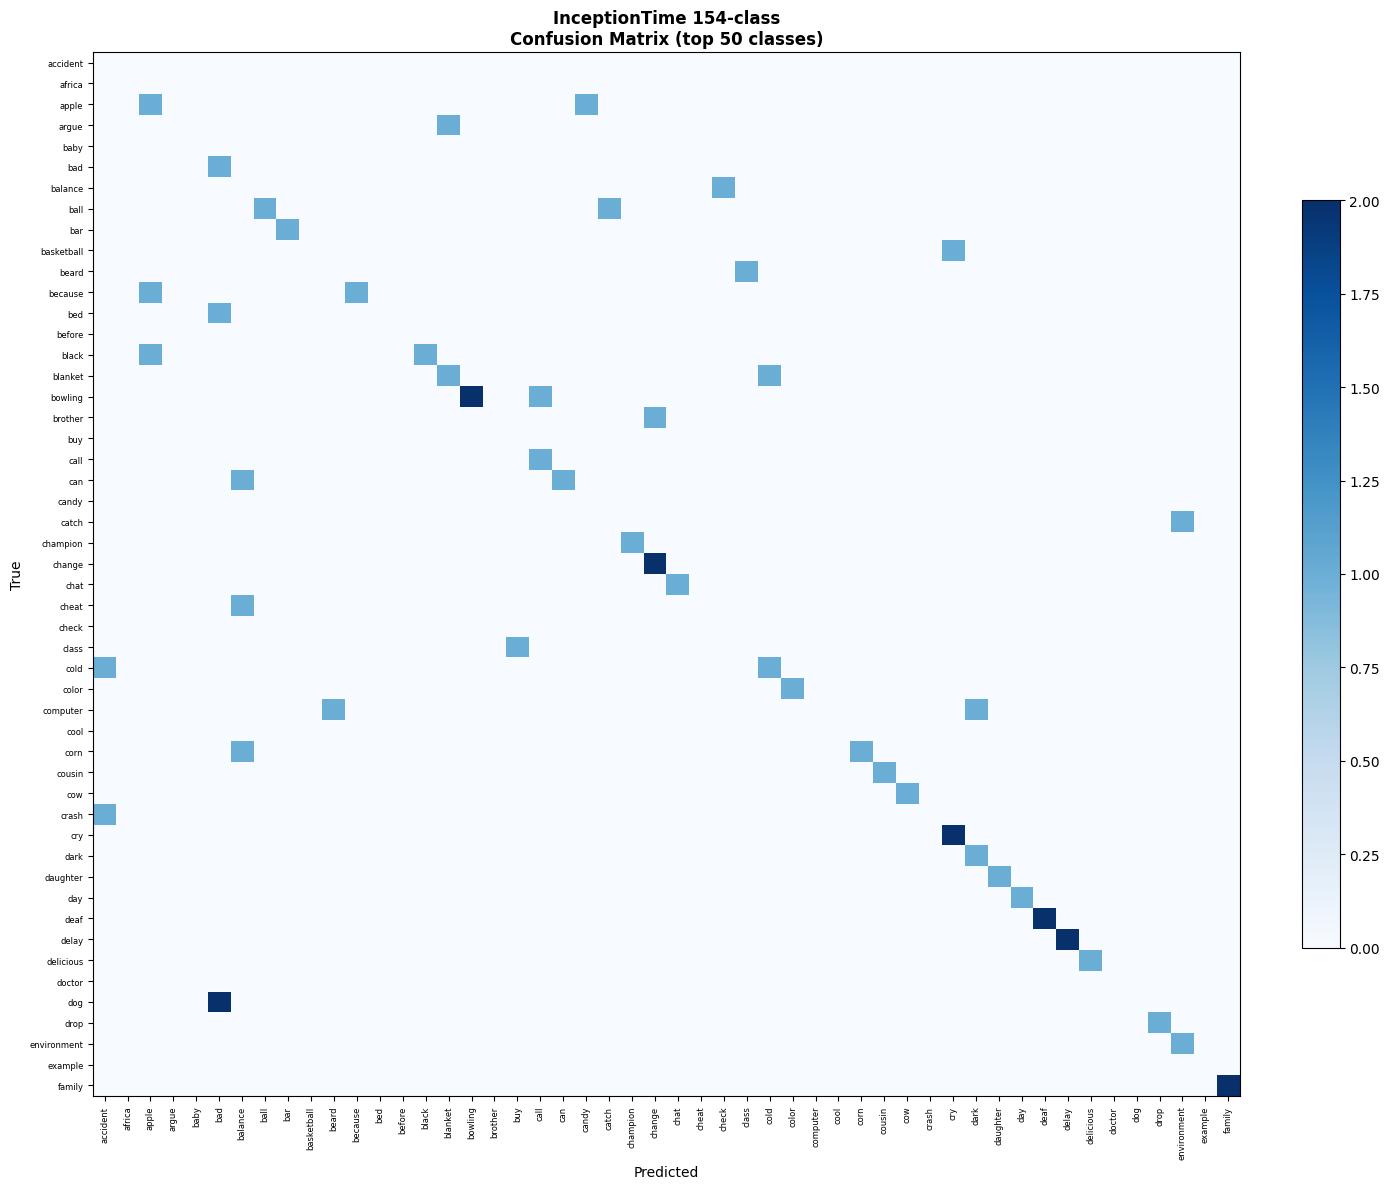

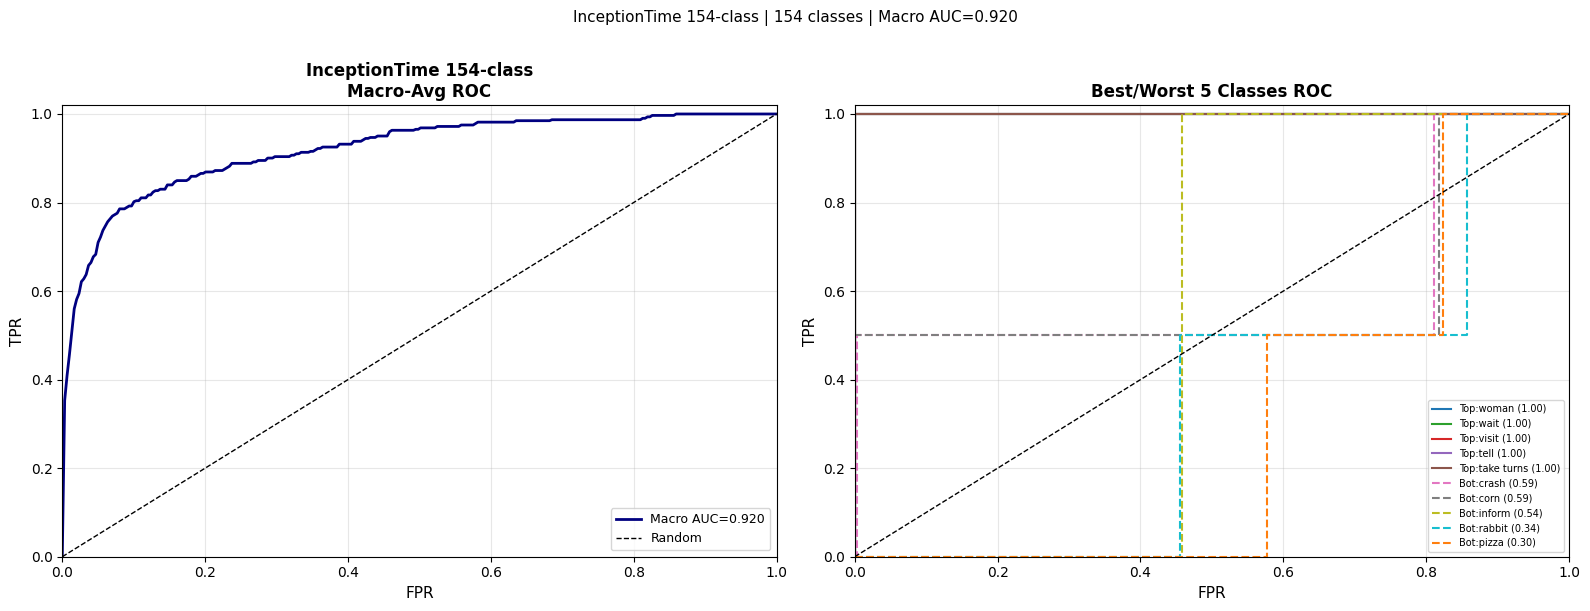

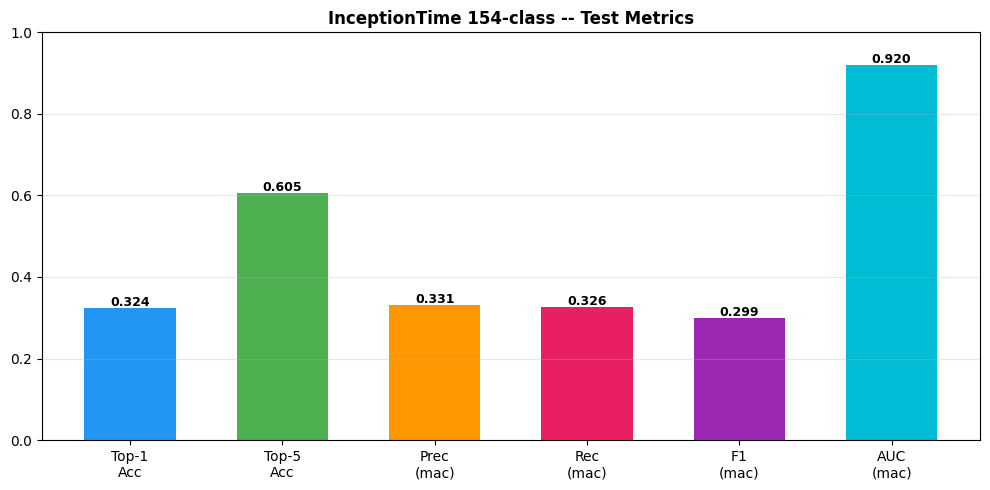


== InceptionTime 154-class ==
  Top-1 : 32.36%  Top-5 : 60.52%
  Prec  : 33.12%  Rec   : 32.58%
  F1    : 29.85%  AUC   : 0.9196

All outputs saved -> /content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/OBrown_DIS9300_v2/results/inc_154


In [ ]:
results = full_eval(y_test, y_proba, le, MODEL_NAME, MODEL_TAG, RESULTS_DIR)
print(f'\nAll outputs saved -> {RESULTS_DIR}')


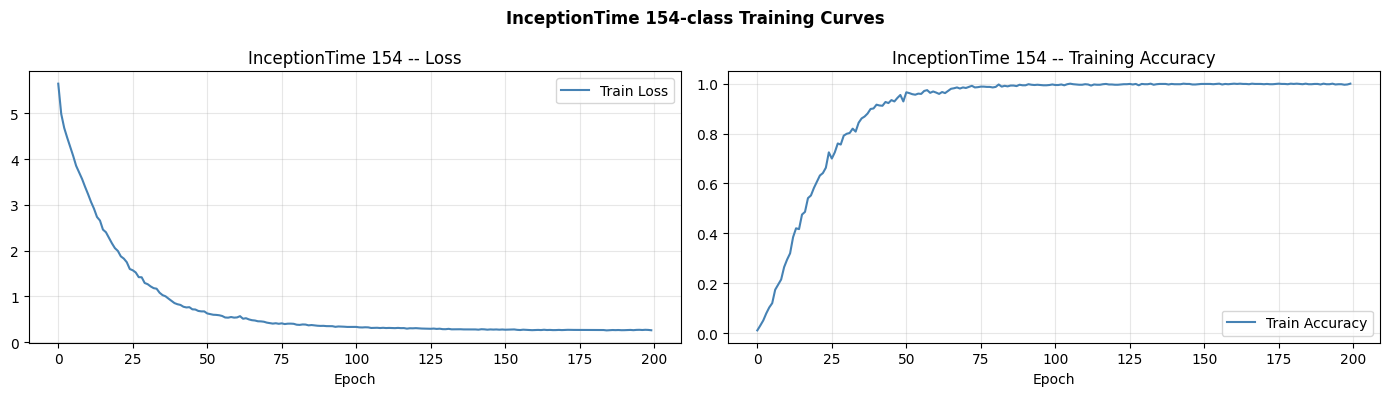

In [ ]:
if os.path.exists(HISTORY_PATH):
    with open(HISTORY_PATH) as f: hist = json.load(f)
    fig, axes = plt.subplots(1,2,figsize=(14,4))
    axes[0].plot(hist['loss'], color='steelblue', label='Train Loss')
    axes[0].set_title('InceptionTime 154 -- Loss')
    axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(hist['accuracy'], color='steelblue', label='Train Accuracy')
    axes[1].set_title('InceptionTime 154 -- Training Accuracy')
    axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.suptitle('InceptionTime 154-class Training Curves', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'inc_154_training_curves.png'), dpi=150)
    plt.show()
else:
    print('No history file found (model loaded from cache).')


In [ ]:
import time

def inference_speed_test(model, X, model_label, batch_sizes=(1,8,32,64), n_repeats=5):
    print(f'\n-- Inference speed: {model_label} --')
    results = []
    for bs in batch_sizes:
        sample = X[:bs]
        for _ in range(3):
            model.predict(sample, batch_size=bs, verbose=0)
        times = []
        for _ in range(n_repeats):
            t0 = time.perf_counter()
            model.predict(sample, batch_size=bs, verbose=0)
            times.append(time.perf_counter()-t0)
        mean_ms       = np.mean(times)*1000
        per_sample_ms = mean_ms/bs
        throughput    = bs/np.mean(times)
        print(f'  batch={bs:3d}  total={mean_ms:7.2f}ms  '
              f'per-sample={per_sample_ms:6.2f}ms  '
              f'throughput={throughput:7.1f} samples/s')
        results.append({'model':model_label,'batch_size':bs,
                        'mean_ms':round(mean_ms,2),
                        'per_sample_ms':round(per_sample_ms,2),
                        'throughput_per_s':round(throughput,1)})
    return results

speed_results = inference_speed_test(model, X_test, MODEL_NAME)
speed_df = pd.DataFrame(speed_results)
speed_df.to_csv(os.path.join(RESULTS_DIR,'inc_154_inference_speed.csv'),index=False)
print(f'\nSpeed results saved -> {RESULTS_DIR}/inc_154_inference_speed.csv')
print(speed_df.to_string(index=False))



-- Inference speed: InceptionTime 154-class --
  batch=  1  total= 105.61ms  per-sample=105.61ms  throughput=    9.5 samples/s
  batch=  8  total= 100.18ms  per-sample= 12.52ms  throughput=   79.9 samples/s
  batch= 32  total=  70.17ms  per-sample=  2.19ms  throughput=  456.1 samples/s
  batch= 64  total=  71.71ms  per-sample=  1.12ms  throughput=  892.4 samples/s

Speed results saved -> /content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/OBrown_DIS9300_v2/results/inc_154/inc_154_inference_speed.csv
                  model  batch_size  mean_ms  per_sample_ms  throughput_per_s
InceptionTime 154-class           1   105.61         105.61               9.5
InceptionTime 154-class           8   100.18          12.52              79.9
InceptionTime 154-class          32    70.17           2.19             456.1
InceptionTime 154-class          64    71.71           1.12             892.4


In [2]:
from google.colab import drive, userdata
drive.mount('/content/drive')
# Click the link, sign in, paste the code — Drive is now mounted

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
import subprocess, os

# ── USER CONFIG ── fill these in ──────────────────────────────
GITHUB_USERNAME = "o-brown7025"
GITHUB_REPO     = "OBrown_DIS9300A_v1_ASLR"   # your repo name
GIT_EMAIL       = "o.brown7025@student.nu.edu"
COMMIT_MSG      = "Initial commit: add notebooks, results, data + README"
# ─────────────────────────────────────────────────────────────

# Read PAT from Colab Secrets (add it via the 🔑 sidebar icon)
# Replace 'YOUR_SECRET_NAME' with the actual name you gave your GitHub PAT in Colab Secrets.
GITHUB_TOKEN = userdata.get('OBrown_DIS9300A_v1_ASLR')

subprocess.run(["git", "config", "--global", "user.name",  GITHUB_USERNAME])
subprocess.run(["git", "config", "--global", "user.email", GIT_EMAIL])
print("✓ Git configured")

✓ Git configured


In [29]:
import os

# Reset working directory first
os.chdir("/content")

REPO_URL = f"https://{GITHUB_TOKEN}@github.com/{GITHUB_USERNAME}/{GITHUB_REPO}.git"
LOCAL_REPO = f"/content/{GITHUB_REPO}"

if os.path.exists(LOCAL_REPO):
    subprocess.run(["rm", "-rf", LOCAL_REPO])

result = subprocess.run(["git", "clone", REPO_URL, LOCAL_REPO], capture_output=True, text=True)
print(result.stdout or f"✓ Repo cloned to {LOCAL_REPO}")
if result.returncode != 0:
    print("ERROR:", result.stderr)

✓ Repo cloned to /content/OBrown_DIS9300A_v1_ASLR


In [30]:
import shutil, pathlib

BASE_DRIVE = "/content/drive/MyDrive/Consultant/Colab_Notebooks/Obrown_Dissertation_NU_25/OBrown_DIS9300_v2"

SOURCES = {
    "Jupyter_Notebooks/Git_DIS9300_v2": "notebooks",
    "results/end_point":              "results",
    "data":                           "data",
}

for src_rel, dest_name in SOURCES.items():
    src  = pathlib.Path(BASE_DRIVE) / src_rel
    dest = pathlib.Path(LOCAL_REPO) / dest_name
    if dest.exists():
        shutil.rmtree(dest)
    shutil.copytree(src, dest)
    count = len(list(dest.rglob("*")))
    print(f"✓ {src_rel}  →  {dest_name}/  ({count} items)")

✓ Jupyter_Notebooks/Git_DIS9300_v2  →  notebooks/  (29 items)
✓ results/end_point  →  results/  (101 items)
✓ data  →  data/  (57 items)


In [31]:
import base64

# ── Embed DIS-9300.png as base64 so it always renders ──────────
png_candidates = list(pathlib.Path(LOCAL_REPO).rglob("DIS-9300.png"))
img_tag = ""
if png_candidates:
    img_path = png_candidates[0]
    img_b64  = base64.b64encode(img_path.read_bytes()).decode()
    img_tag  = f'\n\n![DIS-9300](data:image/png;base64,{img_b64})\n'
    print(f"✓ Found image: {img_path.relative_to(LOCAL_REPO)}")
else:
    print("⚠ DIS-9300.png not found — image section will be skipped")

# ── Build file tree listing ─────────────────────────────────────
def tree_md(folder, indent=0):
    lines = []
    for p in sorted(pathlib.Path(folder).iterdir()):
        prefix = "  " * indent + ("📁 " if p.is_dir() else "📄 ")
        lines.append(f"- {prefix}`{p.name}`")
        if p.is_dir() and indent < 2:
            lines.extend(tree_md(p, indent+1))
    return lines

tree_lines = "\n".join(tree_md(LOCAL_REPO))

readme = f"""# OBrown_DIS9300A_v1_ASLR

**Dissertation project repository — National University, 2025**
Researcher: O. Brown | Course: DIS 9300
{img_tag}
---

## Repository structure

{tree_lines}

---

## Folder descriptions

| Folder | Contents |
|---|---|
| `notebooks/` | Jupyter notebooks for all analysis stages |
| `results/` | End-point outputs (figures, tables, exports) |
| `data/` | Raw and processed datasets |

---

*Auto-generated by Colab transfer script.*
"""

readme_path = pathlib.Path(LOCAL_REPO) / "README.md"
readme_path.write_text(readme)
print("✓ README.md written")

✓ Found image: results/DIS-9300.png
✓ README.md written


In [33]:
import subprocess, os

os.chdir(LOCAL_REPO)

# Split the push into smaller batches to avoid timeout
# First, set a larger buffer size
subprocess.run(["git", "config", "http.postBuffer", "524288000"])  # 500MB buffer
subprocess.run(["git", "config", "http.lowSpeedLimit", "0"])
subprocess.run(["git", "config", "http.lowSpeedTime", "999999"])

# Try push with compression disabled (faster for large files)
subprocess.run(["git", "config", "core.compression", "0"])

push = subprocess.run(
    ["git", "push", "--verbose", "origin", "HEAD"],
    capture_output=True, text=True
)
print(push.stdout)
print(push.stderr)

if push.returncode == 0:
    print(f"\n✅ Done! https://github.com/{GITHUB_USERNAME}/{GITHUB_REPO}")
else:
    print("\n❌ Still failing — see partial push option below")


Pushing to https://github.com/o-brown7025/OBrown_DIS9300A_v1_ASLR.git
POST git-receive-pack (chunked)
error: RPC failed; HTTP 408 curl 22 The requested URL returned error: 408
send-pack: unexpected disconnect while reading sideband packet
fatal: the remote end hung up unexpectedly
Everything up-to-date


❌ Still failing — see partial push option below


In [32]:
os.chdir(LOCAL_REPO)

subprocess.run(["git", "add", "."])

status = subprocess.run(["git", "status", "--short"], capture_output=True, text=True)
print(status.stdout)

commit = subprocess.run(["git", "commit", "-m", COMMIT_MSG],
                        capture_output=True, text=True)
print(commit.stdout)

push = subprocess.run(["git", "push", "origin", "HEAD"],
                      capture_output=True, text=True)
print(push.stdout or push.stderr)

if push.returncode == 0:
    print(f"\n✅ Done! Visit: https://github.com/{GITHUB_USERNAME}/{GITHUB_REPO}")
else:
    print("\n❌ Push failed — check your PAT permissions (needs 'repo' scope)")

A  README.md
A  data/csv/ASL_154_test_rf.csv
A  data/csv/ASL_154_train_rf.csv
A  data/csv/ASL_full_test.csv
A  data/csv/ASL_full_train.csv
A  data/csv/ASL_reduced_test.csv
A  data/csv/ASL_reduced_train.csv
A  data/csv/ASL_s11_test.csv
A  data/csv/ASL_s11_train.csv
A  data/csv/ASL_s11_train_aug.csv
A  data/csv/ASL_signer2_test.csv
A  data/csv/ASL_signer2_train.csv
A  data/csv/ASL_signer2_train_aug.csv
A  data/csv/ASL_signer_test.csv
A  data/csv/ASL_signer_train.csv
A  data/meta/ASL_154_label_encoder.pkl
A  data/meta/ASL_154_meta.json
A  data/meta/channel_selector.pkl
A  data/meta/channel_selector_243.pkl
A  data/meta/channel_selector_243_v2.pkl
A  data/meta/channel_selector_full_v2.pkl
A  data/meta/channel_selector_s11.pkl
A  data/meta/channel_selector_signer.pkl
A  data/meta/channel_selector_signer2.pkl
A  data/meta/class_distribution.png
A  data/meta/imputer_channel_means.pkl
A  data/meta/pca_biplot.png
A  data/meta/pca_loadings_heatmap.png
A  data/meta/pca_scree_plot.png
A  data/meta

In [ ]:
import subprocess, os

os.chdir(LOCAL_REPO)

subprocess.run(["git", "config", "http.postBuffer", "524288000"])
subprocess.run(["git", "config", "http.lowSpeedLimit", "0"])
subprocess.run(["git", "config", "http.lowSpeedTime", "999999"])

# Push data folder first
subprocess.run(["git", "rm", "-r", "--cached", "notebooks/", "results/"])
subprocess.run(["git", "commit", "-m", "push: data only first"])
push1 = subprocess.run(["git", "push", "origin", "HEAD"], capture_output=True, text=True)
print("Data push:", "✅" if push1.returncode == 0 else "❌", push1.stderr[:200])

# Re-add notebooks
subprocess.run(["git", "add", "notebooks/"])
subprocess.run(["git", "commit", "-m", "push: add notebooks"])
push2 = subprocess.run(["git", "push", "origin", "HEAD"], capture_output=True, text=True)
print("Notebooks push:", "✅" if push2.returncode == 0 else "❌", push2.stderr[:200])

# Re-add results
subprocess.run(["git", "add", "results/"])
subprocess.run(["git", "commit", "-m", "push: add results"])
push3 = subprocess.run(["git", "push", "origin", "HEAD"], capture_output=True, text=True)
print("Results push:", "✅" if push3.returncode == 0 else "❌", push3.stderr[:200])

Data push: ❌ error: RPC failed; HTTP 408 curl 22 The requested URL returned error: 408
send-pack: unexpected disconnect while reading sideband packet
fatal: the remote end hung up unexpectedly
Everything up-to-dat


In [ ]:
import pathlib

repo = pathlib.Path(LOCAL_REPO)
files = [(p, p.stat().st_size) for p in repo.rglob("*") if p.is_file()]
files.sort(key=lambda x: x[1], reverse=True)

print(f"Total files: {len(files)}")
print(f"\nTop 20 largest files:")
for p, size in files[:20]:
    print(f"  {size/1e6:.1f} MB  {p.relative_to(repo)}")

total = sum(s for _, s in files)
print(f"\nTotal size: {total/1e6:.1f} MB")
large = [(p,s) for p,s in files if s > 10_000_000]
print(f"Files over 10MB: {len(large)}")